In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw.csv", parse_dates=["date"])
df = df.drop_duplicates("date").sort_values("date").reset_index(drop=True)

print(df.info())
print(df.isna().sum())
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       365 non-null    datetime64[us]
 1   btc_price  365 non-null    float64       
 2   eth_price  365 non-null    float64       
dtypes: datetime64[us](1), float64(2)
memory usage: 8.7 KB
None
date         0
btc_price    0
eth_price    0
dtype: int64


,date,btc_price,eth_price
count,365,365.000000,365.000000
mean,2026-04-03 00:00:00,79715.133109,2513.324555
min,2025-10-03 00:00:00,58566.091992,1566.008130
25%,2026-01-02 00:00:00,66822.552303,1967.928380
50%,2026-04-03 00:00:00,77261.627221,2326.445177
75%,2026-07-03 00:00:00,88672.329679,2977.664504
max,2026-10-02 00:00:00,124739.810888,4690.837856
std,NaN,15116.410952,695.272744


Data check: 365 daily rows (Oct 2025 to Oct 2026), no missing values, no duplicate dates. Data is clean, so no imputation was needed.

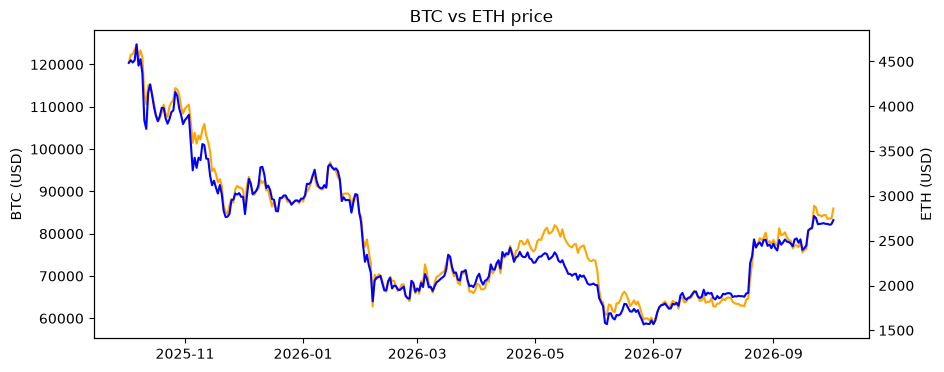

In [12]:
fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(df["date"], df["btc_price"], color="orange")
ax1.set_ylabel("BTC (USD)")
ax2 = ax1.twinx()
ax2.plot(df["date"], df["eth_price"], color="blue")
ax2.set_ylabel("ETH (USD)")
plt.title("BTC vs ETH price")
plt.show()

BTC and ETH broadly move together over the year. ETH is more volatile: its swings are larger in percentage terms. This suggests a linear relationship may exist.

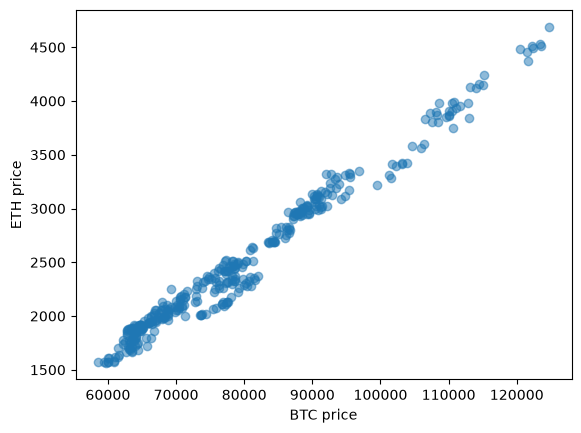

,btc_price,eth_price
btc_price,1.000000,0.988812
eth_price,0.988812,1.000000


In [13]:
plt.scatter(df["btc_price"], df["eth_price"], alpha=0.5)
plt.xlabel("BTC price")
plt.ylabel("ETH price")
plt.show()

df[["btc_price", "eth_price"]].corr()

The scatter plot is almost a straight line and the correlation is very high, so simple linear regression is a reasonable choice. Caveat: both prices trend over time, so high correlation can partly come from trending together.

In [14]:
split = int(len(df) * 0.8)
train, test = df.iloc[:split], df.iloc[split:]

X_train, y_train = train[["btc_price"]], train["eth_price"]
X_test, y_test = test[["btc_price"]], test["eth_price"]

print("Train:", train["date"].min().date(), "to", train["date"].max().date())
print("Test :", test["date"].min().date(), "to", test["date"].max().date())

Train: 2025-10-03 to 2026-07-21
Test : 2026-07-22 to 2026-10-02


I used a time-based 80/20 split instead of a random split. Random splitting would put future data in training (data leakage), which is invalid for time series.

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

model = LinearRegression().fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)

print("Slope (coef):", model.coef_[0])
print("Intercept   :", model.intercept_)
print("Train R2:", r2_score(y_train, y_train_pred))
print("Test  R2:", r2_score(y_test, y_pred))
print("Test MAE:", mean_absolute_error(y_test, y_pred))


Slope (coef): 0.04618770497700256
Intercept   : -1181.2183717392113
Train R2: 0.9790308745201471
Test  R2: 0.9230241373831123
Test MAE: 75.60464159493469


Slope 0.046: a $1,000 rise in BTC goes with about $46 rise in ETH on average. Train R² 0.979 vs test R² 0.923: small gap, so no serious overfitting. Test MAE is about $76.

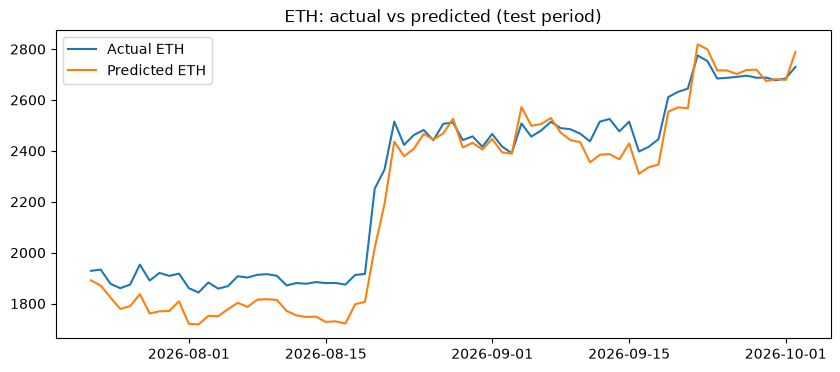

In [16]:
plt.figure(figsize=(10, 4))
plt.plot(test["date"], y_test, label="Actual ETH")
plt.plot(test["date"], y_pred, label="Predicted ETH")
plt.legend()
plt.title("ETH: actual vs predicted (test period)")
plt.show()

Yahan tumhe khud plot dekhke likhna hai ki prediction kahan achhi hai aur kahan door. Template:

The predicted line follows the actual ETH price closely. Errors are larger around (sharp moves / specific period), where the model misses ETH-specific swings.

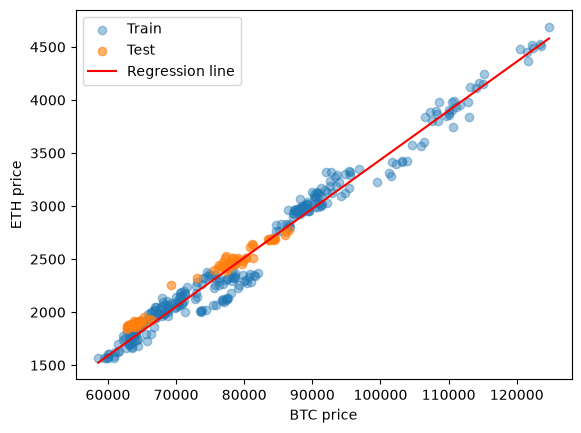

In [17]:
plt.scatter(X_train, y_train, alpha=0.4, label="Train")
plt.scatter(X_test, y_test, alpha=0.6, label="Test")
xs = df[["btc_price"]].sort_values("btc_price")
plt.plot(xs, model.predict(xs), color="red", label="Regression line")
plt.xlabel("BTC price"); plt.ylabel("ETH price")
plt.legend()
plt.show()

Test points sit close to the fitted line. (Agar test ke points line se upar ya neeche hain toh likho, jaise "Test points lie slightly above the line, so the model underpredicts ETH in the test period.")

In [18]:
import numpy as np
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print("Test MAPE: %.2f%%" % mape)
print("ETH test range:", y_test.min(), "to", y_test.max())
print("BTC train range:", X_train["btc_price"].min(), "to", X_train["btc_price"].max())
print("BTC test range :", X_test["btc_price"].min(), "to", X_test["btc_price"].max())

Test MAPE: 3.61%
ETH test range: 1843.443563411847 to 2775.168682671196
BTC train range: 58566.091991843154 to 124739.81088811433
BTC test range : 62772.57726413174 to 86596.74004249526


MAPE of X% means predictions are off by about X% on average. Test BTC range vs train range: (likho andar hai ya bahar). If outside, the model is extrapolating, which is less reliable.

In [19]:
df["days"] = (df["date"] - df["date"].min()).dt.days
Xb_train, Xb_test = df.loc[train.index, ["days"]], df.loc[test.index, ["days"]]

model_b = LinearRegression().fit(Xb_train, y_train)
yb_pred = model_b.predict(Xb_test)

print("Model A (BTC -> ETH)  Test R2: %.3f  MAE: %.1f" % (r2_score(y_test, y_pred), mean_absolute_error(y_test, y_pred)))
print("Model B (days -> ETH) Test R2: %.3f  MAE: %.1f" % (r2_score(y_test, yb_pred), mean_absolute_error(y_test, yb_pred)))

Model A (BTC -> ETH)  Test R2: 0.923  MAE: 75.6
Model B (days -> ETH) Test R2: -13.404  MAE: 1137.8


Model B (time only) gives test R² of -13.4, worse than predicting the mean. The upward trend in the training period did not continue, so time alone is a poor predictor. BTC price is far more informative (R² 0.92).

In [20]:
rets = df[["date", "btc_price", "eth_price"]].copy()
rets["btc_ret"] = rets["btc_price"].pct_change()
rets["eth_ret"] = rets["eth_price"].pct_change()
rets = rets.dropna().reset_index(drop=True)

s = int(len(rets) * 0.8)
Xr_train, yr_train = rets.loc[:s-1, ["btc_ret"]], rets.loc[:s-1, "eth_ret"]
Xr_test, yr_test = rets.loc[s:, ["btc_ret"]], rets.loc[s:, "eth_ret"]

model_r = LinearRegression().fit(Xr_train, yr_train)
yr_pred = model_r.predict(Xr_test)

print("Slope (beta):", model_r.coef_[0])
print("Train R2: %.3f" % r2_score(yr_train, model_r.predict(Xr_train)))
print("Test  R2: %.3f" % r2_score(yr_test, yr_pred))

Slope (beta): 1.296585849961125
Train R2: 0.821
Test  R2: 0.749


On daily returns, test R² is 0.749 and beta is 1.30: when BTC moves 1%, ETH moves about 1.3% on average. The relationship holds beyond shared price trends. Limitation: this is a same-day relationship, not a forecast.

Conclusion: BTC explains most of ETH's price and daily moves, while a time-only baseline fails. Next steps: add more features (volume, other coins), use more history, and try predicting next-day returns.